# Multi-Label Chest X-Ray Pathology Classification using EfficientNet-B0 with Asymmetric Loss

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
try:
    if torch.cuda.is_available():
        # Test CUDA functionality
        test_tensor = torch.zeros(1).cuda()
        DEVICE = 'cuda'
        print(f"GPU Device: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    else:
        DEVICE = 'cpu'
        print("CUDA not available. Using CPU.")
except Exception as e:
    print(f"CUDA test failed: {e}. Falling back to CPU.")
    DEVICE = 'cpu'

print(f"Using device: {DEVICE}\n")

GPU Device: Tesla T4
GPU Memory: 15.64 GB
Using device: cuda



In [3]:
CONFIG = {

    'train_csv'        : '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv',
    'test_csv'         : '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv',
    'sample_sub_csv'   : '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv',
    'image_dir'        : '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images',
    'checkpoint_path'  : '/kaggle/working/best_model.pt',
    'submission_path'  : '/kaggle/working/submission.csv',

    'classes': [
        'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
        'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
        'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum',
        'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta',
        'Calcification of the Aorta', 'No Finding'
    ],

    'image_size'       : 224,
    'imagenet_mean'    : [0.485, 0.456, 0.406],
    'imagenet_std'     : [0.229, 0.224, 0.225],

    'batch_size_train' : 32,
    'batch_size_infer' : 64,
    'num_workers'      : 4,
    'num_epochs'       : 15,
    'frozen_epochs'    : 3,
    'lr'               : 1e-4,
    'weight_decay'     : 1e-4,
    'max_norm'         : 1.0,
    'val_split'        : 0.1,
    'seed'             : 42,

    'T_max'            : 10,

    'gamma_neg'        : 4,
    'gamma_pos'        : 1,
    'clip'             : 0.05,

    'threshold_min'    : 0.10,
    'threshold_max'    : 0.60,
    'threshold_step'   : 0.05,
    'default_threshold': 0.50,
    'low_threshold'    : 0.30,
}

CLASSES     = CONFIG['classes']
NUM_CLASSES = len(CLASSES)
print(f'Number of classes: {NUM_CLASSES}')

Number of classes: 20


In [4]:
train_df = pd.read_csv(CONFIG['train_csv'])
test_df  = pd.read_csv(CONFIG['test_csv'])

print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')
train_df.head(3)

Train shape: (51043, 21)
Test shape : (17015, 1)


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


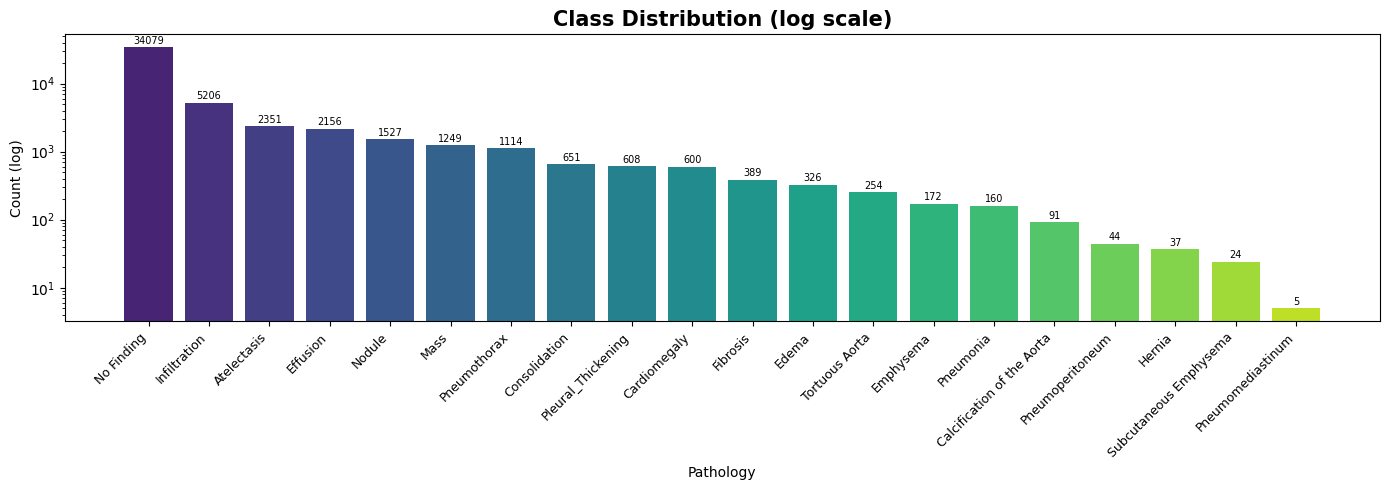


── Class Imbalance Ratios (majority / class_count) ──
  No Finding                         :  34079  ratio=     1.0x
  Infiltration                       :   5206  ratio=     6.5x
  Atelectasis                        :   2351  ratio=    14.5x
  Effusion                           :   2156  ratio=    15.8x
  Nodule                             :   1527  ratio=    22.3x
  Mass                               :   1249  ratio=    27.3x
  Pneumothorax                       :   1114  ratio=    30.6x
  Consolidation                      :    651  ratio=    52.3x
  Pleural_Thickening                 :    608  ratio=    56.1x
  Cardiomegaly                       :    600  ratio=    56.8x
  Fibrosis                           :    389  ratio=    87.6x
  Edema                              :    326  ratio=   104.5x
  Tortuous Aorta                     :    254  ratio=   134.2x
  Emphysema                          :    172  ratio=   198.1x
  Pneumonia                          :    160  ratio=   213.0x


In [5]:
label_counts = train_df[CLASSES].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=plt.cm.viridis(np.linspace(0.1, 0.9, NUM_CLASSES)))
ax.set_yscale('log')
ax.set_title('Class Distribution (log scale)', fontsize=15, fontweight='bold')
ax.set_xlabel('Pathology')
ax.set_ylabel('Count (log)')
ax.set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.05,
            str(int(val)), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print('\n── Class Imbalance Ratios (majority / class_count) ──')
majority = label_counts.max()
for cls, cnt in label_counts.items():
    ratio = majority / cnt if cnt > 0 else float('inf')
    print(f'  {cls:<35s}: {int(cnt):>6d}  ratio={ratio:>8.1f}x')

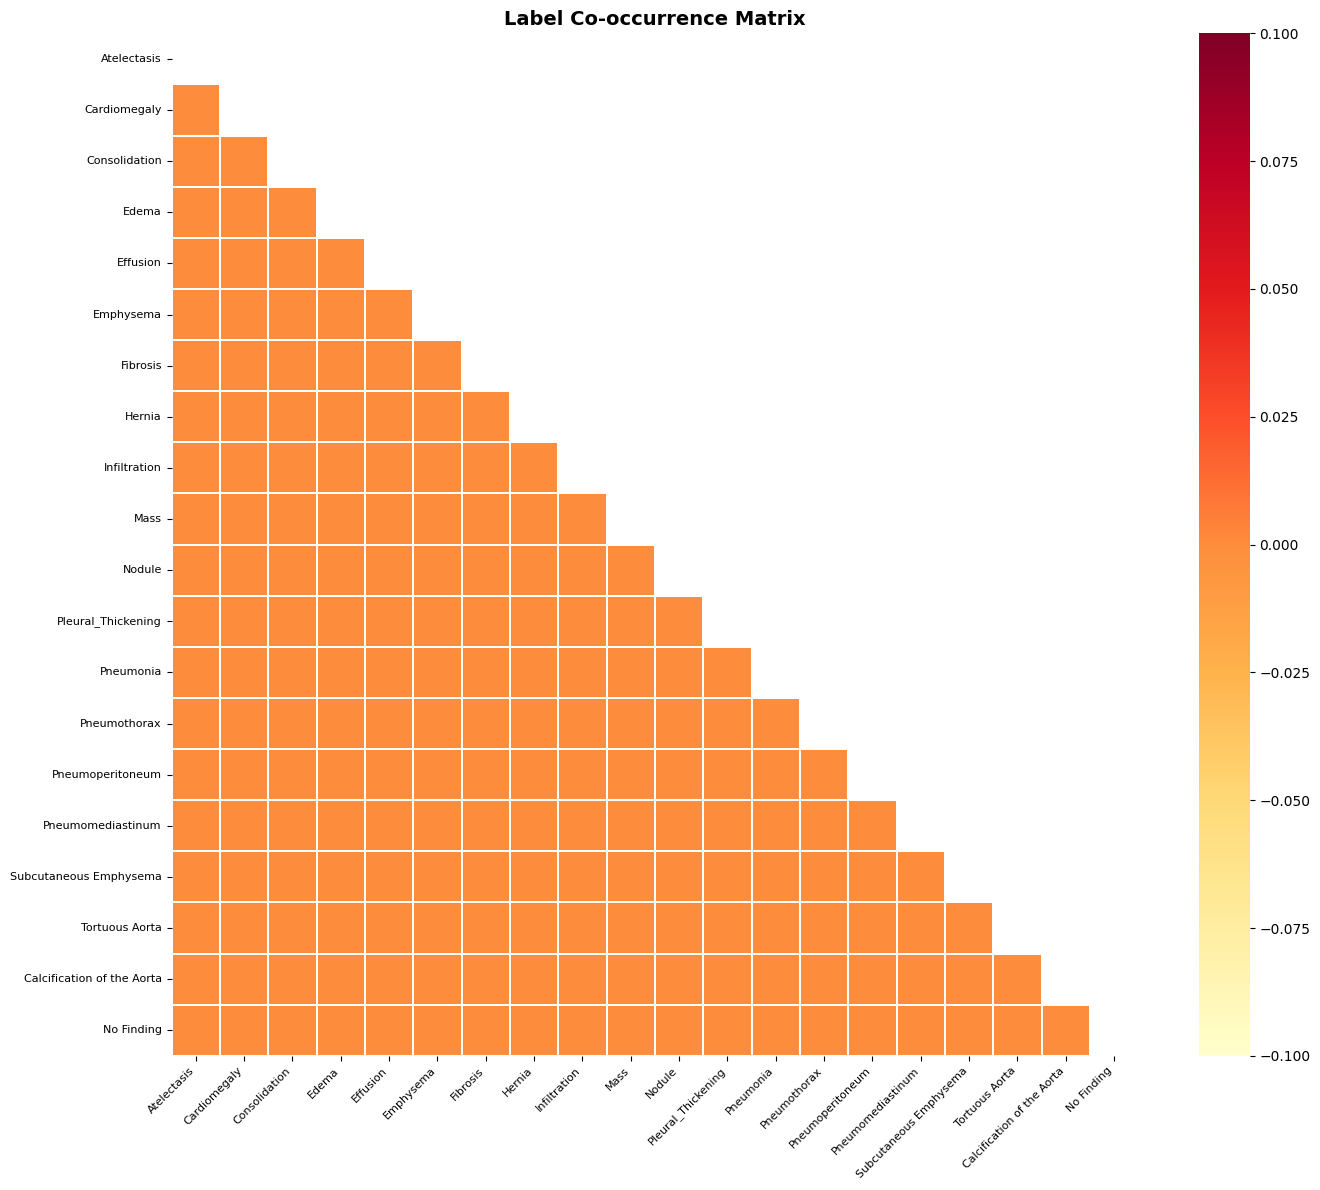

In [6]:
comat = train_df[CLASSES].T.dot(train_df[CLASSES])
np.fill_diagonal(comat.values, 0)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(comat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(comat, annot=False, fmt='d', cmap='YlOrRd',
            linewidths=0.3, ax=ax, mask=mask)
ax.set_title('Label Co-occurrence Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150)
plt.show()

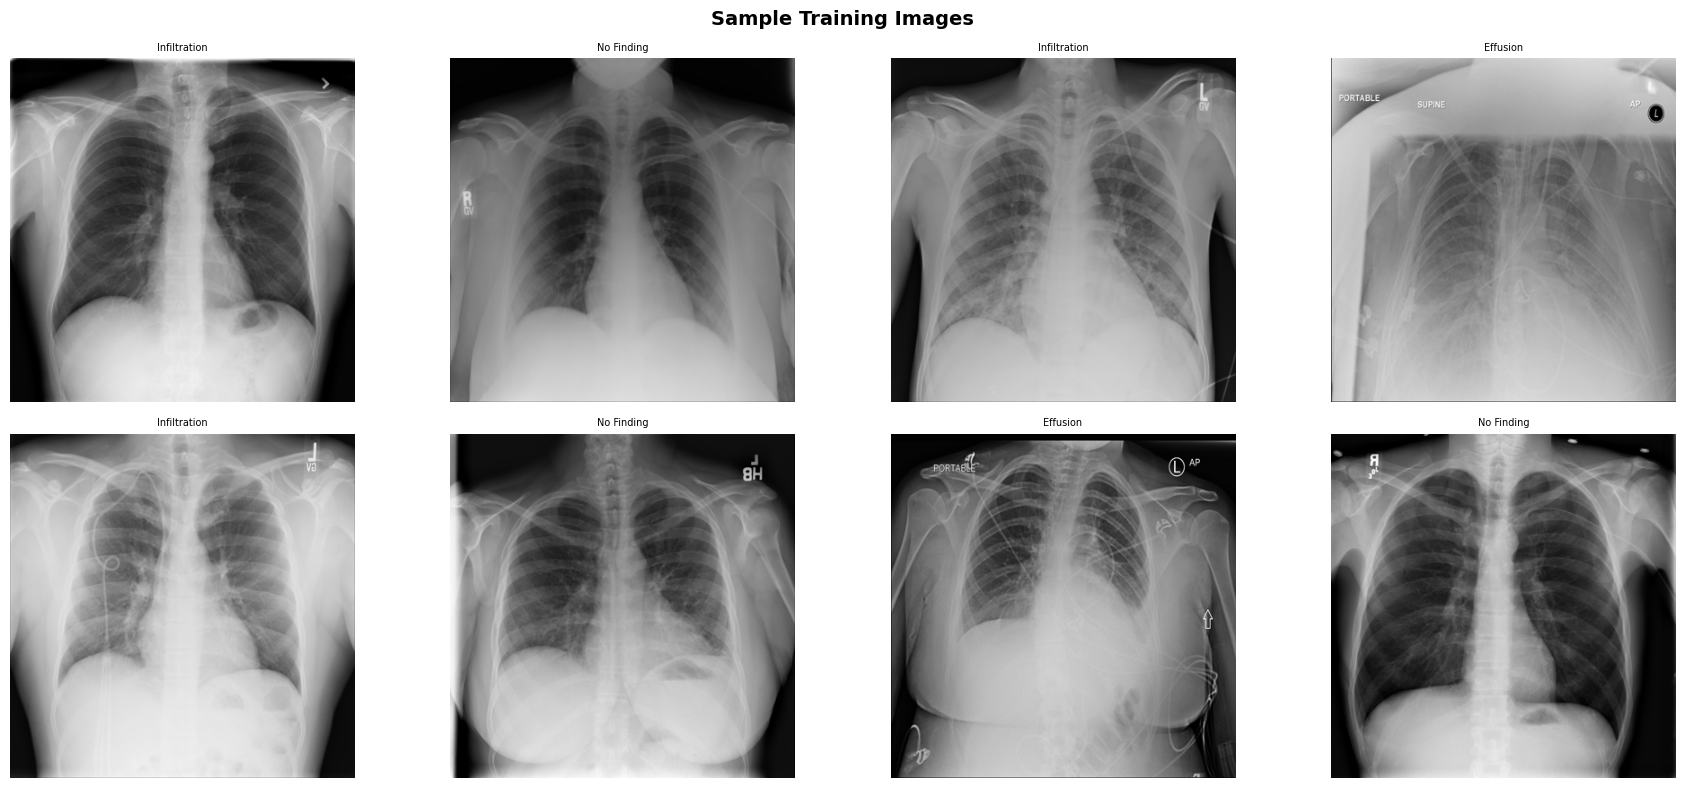

In [7]:
IMAGE_DIR = Path(CONFIG['image_dir'])

def show_sample_images(df, n=8):
    sample = df.sample(n, random_state=42).reset_index(drop=True)
    fig, axes = plt.subplots(2, n//2, figsize=(18, 8))
    axes = axes.flatten()
    for i, row in sample.iterrows():
        img_path = IMAGE_DIR / row['id']
        if img_path.exists():
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center',
                         transform=axes[i].transAxes, fontsize=10, color='red')
        labels = [c for c in CLASSES if row[c] == 1]
        axes[i].set_title('\n'.join(labels) if labels else 'No Finding',
                           fontsize=7)
        axes[i].axis('off')
    plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=120)
    plt.show()

show_sample_images(train_df)

In [8]:
def competition_score(y_true: np.ndarray, y_pred: np.ndarray,
                      thresholds=None) -> float:
    """
    Compute macro-averaged competition score.
    Score_c = (TP_c - FP_c - 5*FN_c) / N_c

    Args:
        y_true     : (N, C) binary ground truth
        y_pred     : (N, C) predicted probabilities
        thresholds : array/list of C thresholds (default 0.5 for all)
    Returns:
        macro score (float)
    """
    C = y_true.shape[1]
    if thresholds is None:
        thresholds = [0.5] * C
    scores = []
    for c in range(C):
        preds = (y_pred[:, c] >= thresholds[c]).astype(int)
        gt    = y_true[:, c].astype(int)
        N_c   = len(gt)
        TP    = int(((preds == 1) & (gt == 1)).sum())
        FP    = int(((preds == 1) & (gt == 0)).sum())
        FN    = int(((preds == 0) & (gt == 1)).sum())
        scores.append((TP - FP - 5 * FN) / N_c)
    return float(np.mean(scores))


def per_class_score(y_true: np.ndarray, y_pred: np.ndarray,
                    thresholds=None) -> dict:
    """Returns per-class score dict."""
    C = y_true.shape[1]
    if thresholds is None:
        thresholds = [0.5] * C
    result = {}
    for c, cls in enumerate(CLASSES):
        preds = (y_pred[:, c] >= thresholds[c]).astype(int)
        gt    = y_true[:, c].astype(int)
        N_c   = len(gt)
        TP    = int(((preds == 1) & (gt == 1)).sum())
        FP    = int(((preds == 1) & (gt == 0)).sum())
        FN    = int(((preds == 0) & (gt == 1)).sum())
        result[cls] = (TP - FP - 5 * FN) / N_c
    return result

print('Competition scoring functions defined.')

Competition scoring functions defined.


In [9]:
IMG_SIZE = CONFIG['image_size']
MEAN     = CONFIG['imagenet_mean']
STD      = CONFIG['imagenet_std']

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Transforms defined.')

Transforms defined.


In [10]:
class XRayDataset(Dataset):
    def __init__(self, df, image_dir, classes, transform=None, is_test=False):
        """
        Args:
            df        : DataFrame with 'id' column (and label columns for train)
            image_dir : path to images folder
            classes   : list of 20 class names
            transform : torchvision transforms
            is_test   : if True, no labels returned
        """
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.classes   = classes
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_dir / row['id']
        image    = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, row['id']

        labels = torch.tensor(row[self.classes].values.astype(np.float32),
                              dtype=torch.float32)
        return image, labels

most_common_label = label_counts.index[0]
print(f'Stratifying on: {most_common_label}')

train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size   = CONFIG['val_split'],
    random_state= CONFIG['seed'],
    stratify    = train_df[most_common_label]
)

train_data = train_df.iloc[train_idx]
val_data   = train_df.iloc[val_idx]
print(f'Train samples: {len(train_data)} | Val samples: {len(val_data)}')

train_dataset = XRayDataset(train_data, CONFIG['image_dir'],
                            CLASSES, transform=train_transforms)
val_dataset   = XRayDataset(val_data,   CONFIG['image_dir'],
                            CLASSES, transform=val_transforms)
test_dataset  = XRayDataset(test_df,    CONFIG['image_dir'],
                            CLASSES, transform=val_transforms, is_test=True)

# GPU-optimized DataLoader configuration
train_loader = DataLoader(train_dataset,
                          batch_size  = CONFIG['batch_size_train'],
                          shuffle     = True,
                          num_workers = 2,  # Reduced from 4 for Kaggle
                          pin_memory  = True,
                          prefetch_factor = 2,
                          persistent_workers = True)
val_loader   = DataLoader(val_dataset,
                          batch_size  = CONFIG['batch_size_infer'],
                          shuffle     = False,
                          num_workers = 2,
                          pin_memory  = True,
                          prefetch_factor = 2,
                          persistent_workers = True)
test_loader  = DataLoader(test_dataset,
                          batch_size  = CONFIG['batch_size_infer'],
                          shuffle     = False,
                          num_workers = 2,
                          pin_memory  = True,
                          prefetch_factor = 2,
                          persistent_workers = True)

print('DataLoaders ready (GPU-optimized).')

Stratifying on: No Finding
Train samples: 45938 | Val samples: 5105
DataLoaders ready (GPU-optimized).


In [11]:
class EfficientNetXRay(nn.Module):
    def __init__(self, num_classes=20, dropout=0.3, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.efficientnet_b0(weights=weights)

        self.features    = backbone.features
        self.avgpool     = nn.AdaptiveAvgPool2d((1, 1))

        # EfficientNet-B0 output: 1280 features
        in_features = 1280
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat = self.features(x)
        feat = self.avgpool(feat)
        feat = feat.view(feat.size(0), -1)
        return self.classifier(feat)

    def freeze_backbone_except_last_block(self):
        """Freeze all feature layers except the last mobile inverted residual block."""
        for name, param in self.features.named_parameters():
            if '8' not in name:  # Keep last block (block 8) trainable
                param.requires_grad = False
        print('Frozen: all except last block + classifier head')

    def unfreeze_all(self):
        """Unfreeze all parameters."""
        for param in self.parameters():
            param.requires_grad = True
        print('Unfrozen: all parameters')


model = EfficientNetXRay(num_classes=NUM_CLASSES, dropout=0.3)
model = model.to(DEVICE)
model.freeze_backbone_except_last_block()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]


Frozen: all except last block + classifier head
Trainable params: 1,078,292 / 4,673,680


In [12]:
class AsymmetricLoss(nn.Module):
    """
    Asymmetric Loss for multi-label classification.
    Paper: https://arxiv.org/abs/2009.14119

    gamma_neg  > gamma_pos  → harder penalty for easy negatives.
    clip       : probability margin (shifts negative probs down by clip).
    """
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05,
                 pos_weight=None, reduction='mean'):
        super().__init__()
        self.gamma_neg  = gamma_neg
        self.gamma_pos  = gamma_pos
        self.clip       = clip
        self.pos_weight = pos_weight  
        self.reduction  = reduction
        self.eps        = 1e-8

    def forward(self, preds, targets):
        xs_pos = preds
        xs_neg = 1 - preds

        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)

        log_pos = torch.log(xs_pos.clamp(min=self.eps))
        log_neg = torch.log(xs_neg.clamp(min=self.eps))

        pt_pos  = xs_pos
        pt_neg  = xs_neg

        loss_pos = targets      * (1 - pt_pos) ** self.gamma_pos * log_pos
        loss_neg = (1 - targets)* (1 - pt_neg) ** self.gamma_neg * log_neg

        if self.pos_weight is not None:
            pw = self.pos_weight.to(preds.device).unsqueeze(0)  # (1, C)
            loss_pos = pw * loss_pos

        loss = -(loss_pos + loss_neg)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

print('AsymmetricLoss defined.')

AsymmetricLoss defined.


In [13]:
def compute_pos_weights(df, classes, scale=True):
    """
    pos_weight_c = (N - n_pos_c) / (n_pos_c + 1e-6)
    Optionally scale by sqrt to reduce extreme values.
    """
    N = len(df)
    weights = []
    for c in classes:
        n_pos = df[c].sum()
        w = (N - n_pos) / (n_pos + 1e-6)
        weights.append(w)
    weights = np.array(weights, dtype=np.float32)
    if scale:
        weights = np.sqrt(weights)   
    return torch.tensor(weights)

pos_weights = compute_pos_weights(train_data, CLASSES, scale=True)

print('Per-class pos_weights (sqrt-scaled):')
for cls, w in zip(CLASSES, pos_weights.tolist()):
    print(f'  {cls:<35s}: {w:.3f}')

criterion = AsymmetricLoss(
    gamma_neg  = CONFIG['gamma_neg'],
    gamma_pos  = CONFIG['gamma_pos'],
    clip       = CONFIG['clip'],
    pos_weight = pos_weights
)
criterion = criterion.to(DEVICE)
print('\nLoss function ready.')

Per-class pos_weights (sqrt-scaled):
  Atelectasis                        : 4.544
  Cardiomegaly                       : 9.256
  Consolidation                      : 8.790
  Edema                              : 12.397
  Effusion                           : 4.741
  Emphysema                          : 17.076
  Fibrosis                           : 11.479
  Hernia                             : 37.876
  Infiltration                       : 2.970
  Mass                               : 6.286
  Nodule                             : 5.695
  Pleural_Thickening                 : 9.238
  Pneumonia                          : 17.895
  Pneumothorax                       : 6.710
  Pneumoperitoneum                   : 33.874
  Pneumomediastinum                  : 95.847
  Subcutaneous Emphysema             : 45.685
  Tortuous Aorta                     : 14.066
  Calcification of the Aorta         : 23.505
  No Finding                         : 0.706

Loss function ready.


In [14]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = CONFIG['lr'],
    weight_decay = CONFIG['weight_decay']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['T_max'], eta_min=1e-6
)
scaler = GradScaler()
print('Optimizer, scheduler, and AMP scaler ready.')

Optimizer, scheduler, and AMP scaler ready.


In [15]:
def validate(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            # Non-blocking async transfer to GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            preds = model(images)
            loss  = criterion(preds, labels)
            total_loss += loss.item() * images.size(0)
            all_probs.append(preds.cpu().float().numpy())
            all_labels.append(labels.cpu().float().numpy())

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    avg_loss   = total_loss / len(loader.dataset)

    
    aucs = []
    for c in range(NUM_CLASSES):
        if len(np.unique(all_labels[:, c])) > 1:
            aucs.append(roc_auc_score(all_labels[:, c], all_probs[:, c]))
        else:
            aucs.append(float('nan'))
    macro_auc = np.nanmean(aucs)

    comp_score = competition_score(all_labels, all_probs,
                                   thresholds=[CONFIG['low_threshold']] * NUM_CLASSES)

    return avg_loss, macro_auc, comp_score, all_probs, all_labels

print('validate() helper defined (GPU-optimized).')

validate() helper defined (GPU-optimized).


In [16]:
history = {
    'train_loss': [], 'val_loss': [],
    'val_auc': [], 'val_score': []
}

best_score   = -np.inf
best_probs   = None
best_labels  = None

for epoch in range(1, CONFIG['num_epochs'] + 1):

    if epoch == CONFIG['frozen_epochs'] + 1:
        model.unfreeze_all()
        optimizer = optim.AdamW(model.parameters(),
                                lr=CONFIG['lr'],
                                weight_decay=CONFIG['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG['T_max'], eta_min=1e-6
        )

    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{CONFIG["num_epochs"]} [Train]',
                leave=False)

    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast():                         # mixed precision forward
            preds = model(images)
            loss  = criterion(preds, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG['max_norm'])
        scaler.step(optimizer)
        scaler.update()

    train_loss = running_loss / len(train_loader.dataset)

    val_loss, val_auc, val_score, vprobs, vlabels = validate(
        model, val_loader, criterion, device=DEVICE
    )

    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_score'].append(val_score)

    print(f'Epoch {epoch:02d}/{CONFIG["num_epochs"]} | '
          f'lr={lr_now:.2e} | '
          f'train_loss={train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | '
          f'val_AUC={val_auc:.4f} | '
          f'val_score={val_score:.4f}')

    if val_score > best_score:
        best_score  = val_score
        best_probs  = vprobs.copy()
        best_labels = vlabels.copy()
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'score'      : best_score,
        }, CONFIG['checkpoint_path'])
        print(f'  New best model saved (score={best_score:.4f})')

print(f'\nTraining complete. Best val score: {best_score:.4f}')

Epoch 01/15 | lr=9.76e-05 | train_loss=0.0000 | val_loss=0.0543 | val_AUC=0.6786 | val_score=-0.8069
  New best model saved (score=-0.8069)


Epoch 02/15 | lr=9.05e-05 | train_loss=0.0000 | val_loss=0.0539 | val_AUC=0.6935 | val_score=-0.7294
  New best model saved (score=-0.7294)


Epoch 03/15 | lr=7.96e-05 | train_loss=0.0000 | val_loss=0.0530 | val_AUC=0.7214 | val_score=-0.7400
Unfrozen: all parameters


Epoch 04/15 | lr=9.76e-05 | train_loss=0.0000 | val_loss=0.0510 | val_AUC=0.7652 | val_score=-0.6496
  New best model saved (score=-0.6496)


Epoch 05/15 | lr=9.05e-05 | train_loss=0.0000 | val_loss=0.0505 | val_AUC=0.7804 | val_score=-0.6260
  New best model saved (score=-0.6260)


...

Epoch 11/15 | lr=1.05e-05 | train_loss=0.0000 | val_loss=0.0565 | val_AUC=0.8091 | val_score=-0.3751
  New best model saved (score=-0.3751)


Epoch 12/15 | lr=3.42e-06 | train_loss=0.0000 | val_loss=0.0572 | val_AUC=0.8109 | val_score=-0.3656
  New best model saved (score=-0.3656)


Epoch 13/15 | lr=1.00e-06 | train_loss=0.0000 | val_loss=0.0571 | val_AUC=0.8114 | val_score=-0.3599
  New best model saved (score=-0.3599)


Epoch 14/15 | lr=3.42e-06 | train_loss=0.0000 | val_loss=0.0574 | val_AUC=0.8105 | val_score=-0.3582
  New best model saved (score=-0.3582)


Epoch 15/15 | lr=1.05e-05 | train_loss=0.0000 | val_loss=0.0578 | val_AUC=0.8100 | val_score=-0.3519
  New best model saved (score=-0.3519)

Training complete. Best val score: -0.3519


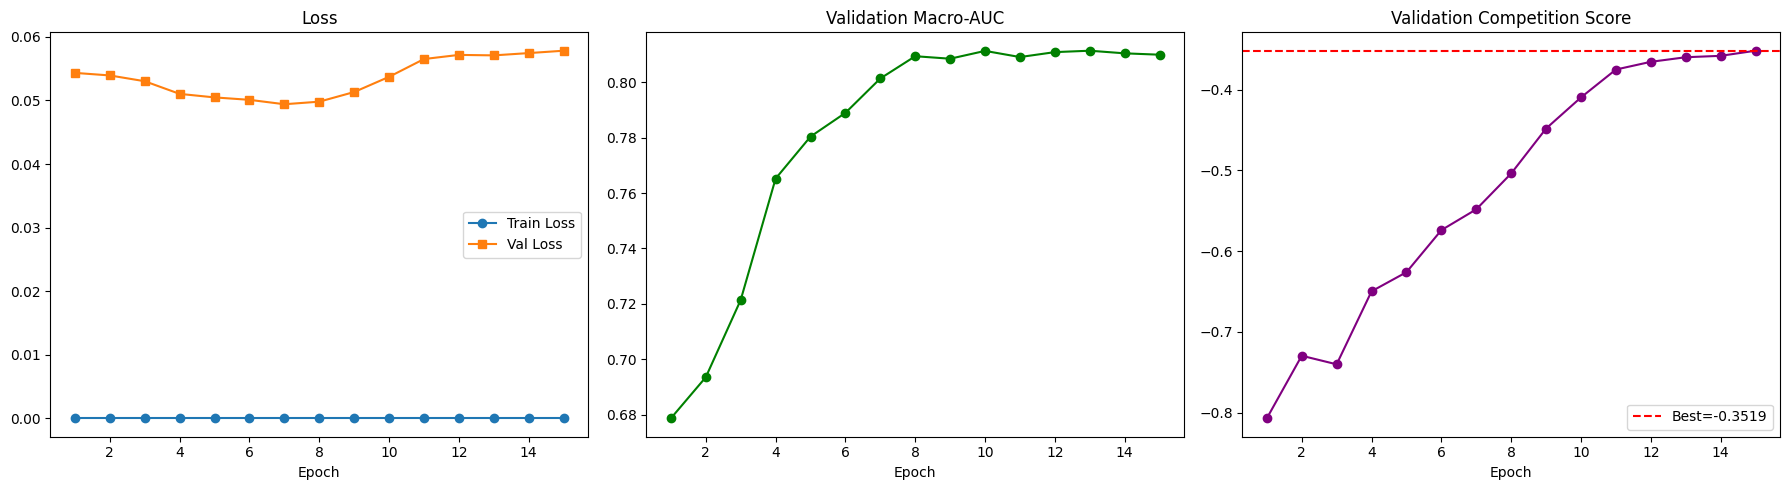

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, CONFIG['num_epochs'] + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['val_auc'], color='green', marker='o')
axes[1].set_title('Validation Macro-AUC'); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_score'], color='purple', marker='o')
axes[2].axhline(best_score, linestyle='--', color='red', label=f'Best={best_score:.4f}')
axes[2].set_title('Validation Competition Score'); axes[2].legend()
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [18]:
thresholds_to_try = np.arange(
    CONFIG['threshold_min'],
    CONFIG['threshold_max'] + CONFIG['threshold_step'] / 2,
    CONFIG['threshold_step']
).round(3)

print(f'Sweeping thresholds for validation analysis: {thresholds_to_try.tolist()}')
print('(Note: Final submission uses argmax one-hot encoding, not per-class thresholds)\n')

optimal_thresholds = []
threshold_results  = []

for c, cls in enumerate(CLASSES):
    best_thr   = 0.5
    best_sc    = -np.inf
    gt         = best_labels[:, c].astype(int)
    N_c        = len(gt)
    probs_c    = best_probs[:, c]

    for thr in thresholds_to_try:
        preds = (probs_c >= thr).astype(int)
        TP = int(((preds == 1) & (gt == 1)).sum())
        FP = int(((preds == 1) & (gt == 0)).sum())
        FN = int(((preds == 0) & (gt == 1)).sum())
        sc = (TP - FP - 5 * FN) / N_c
        if sc > best_sc:
            best_sc  = sc
            best_thr = thr

    optimal_thresholds.append(float(best_thr))
    threshold_results.append({'class': cls, 'threshold': best_thr,
                               'score': best_sc})

score_05  = competition_score(best_labels, best_probs,
                              [CONFIG['default_threshold']] * NUM_CLASSES)
score_03  = competition_score(best_labels, best_probs,
                              [CONFIG['low_threshold']] * NUM_CLASSES)
score_opt = competition_score(best_labels, best_probs, optimal_thresholds)

print(f"Validation Score @ threshold=0.50 (default) : {score_05:.4f}")
print(f"Validation Score @ threshold=0.30           : {score_03:.4f}")
print(f"Validation Score @ optimal per-class thr    : {score_opt:.4f}")
print(f"\n These scores are for validation analysis only.")
print(f"    Final test submission uses argmax one-hot encoding.")

print('\nPer-class optimal thresholds (validation reference only):')
thr_df = pd.DataFrame(threshold_results)
print(thr_df.to_string(index=False))

Sweeping thresholds for validation analysis: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
(Note: Final submission uses argmax one-hot encoding, not per-class thresholds)

Validation Score @ threshold=0.50 (default) : -0.0987
Validation Score @ threshold=0.30           : -0.3519
Validation Score @ optimal per-class thr    : -0.0571

 These scores are for validation analysis only.
    Final test submission uses argmax one-hot encoding.

Per-class optimal thresholds (validation reference only):
                     class  threshold     score
               Atelectasis        0.6 -0.177865
              Cardiomegaly        0.6 -0.046033
             Consolidation        0.6 -0.077179
                     Edema        0.6 -0.040744
                  Effusion        0.6 -0.120274
                 Emphysema        0.6 -0.024682
                  Fibrosis        0.6 -0.054261
                    Hernia        0.6 -0.005877
              Infiltration        0.6 -0.427620
       

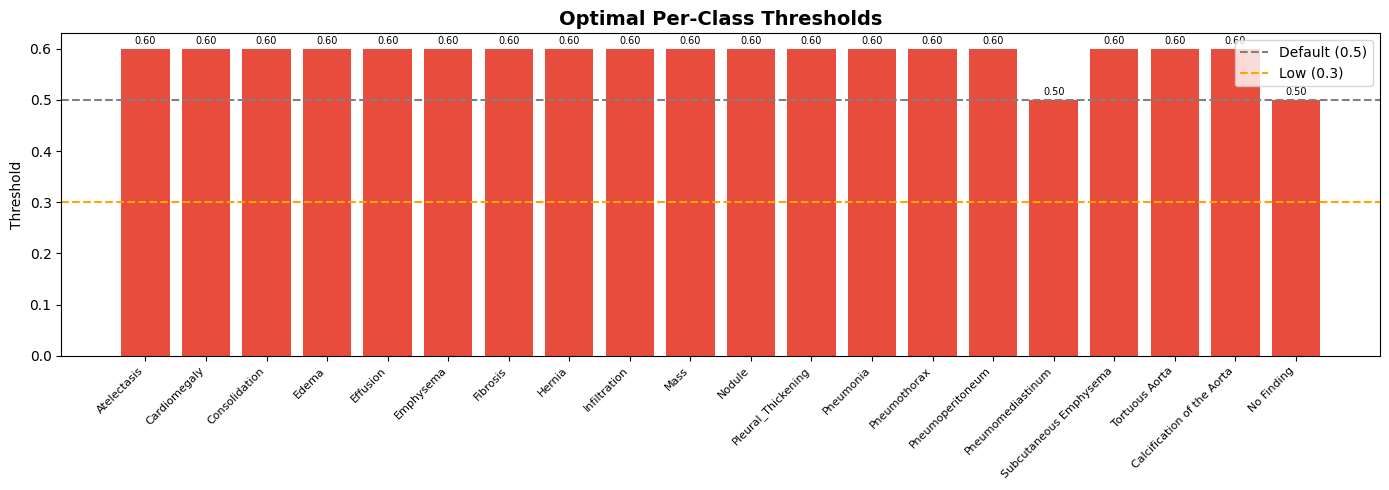

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['#2ecc71' if t <= 0.35 else '#e74c3c' for t in optimal_thresholds]
bars    = ax.bar(CLASSES, optimal_thresholds, color=colors)
ax.axhline(0.5, linestyle='--', color='gray',  label='Default (0.5)')
ax.axhline(0.3, linestyle='--', color='orange',label='Low (0.3)')
ax.set_title('Optimal Per-Class Thresholds', fontsize=14, fontweight='bold')
ax.set_ylabel('Threshold')
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.legend()
for bar, thr in zip(bars, optimal_thresholds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{thr:.2f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('threshold_plot.png', dpi=150)
plt.show()

In [20]:
ckpt = torch.load(CONFIG['checkpoint_path'], map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
      f"(best score={ckpt['score']:.4f})")

model.eval()
all_test_probs = []
all_test_ids   = []

with torch.no_grad():
    for images, img_ids in tqdm(test_loader, desc='Inference'):
       
        images = images.to(DEVICE, non_blocking=True)
        preds = model(images)
        all_test_probs.append(preds.cpu().float().numpy())
        all_test_ids.extend(img_ids)

all_test_probs = np.concatenate(all_test_probs, axis=0)
print(f'Test predictions shape: {all_test_probs.shape}')

test_preds_onehot = np.zeros_like(all_test_probs, dtype=int)
for i in range(all_test_probs.shape[0]):
    max_idx = np.argmax(all_test_probs[i])
    test_preds_onehot[i, max_idx] = 1

print(f'One-hot prediction range: [{test_preds_onehot.min()}, {test_preds_onehot.max()}]')
print(f'Ones per row (should be 1): min={test_preds_onehot.sum(axis=1).min()}, max={test_preds_onehot.sum(axis=1).max()}, mean={test_preds_onehot.sum(axis=1).mean():.2f}')

Loaded checkpoint from epoch 15 (best score=-0.3519)


Inference: 100%|██████████| 266/266 [01:48<00:00,  2.45it/s]

Test predictions shape: (17015, 20)
One-hot prediction range: [0, 1]
Ones per row (should be 1): min=1, max=1, mean=1.00


In [21]:
sample_sub = pd.read_csv(CONFIG['sample_sub_csv'])
print('Sample submission columns:', sample_sub.columns.tolist())
print('Sample submission shape   :', sample_sub.shape)

sub_df = pd.DataFrame({'id': all_test_ids})
for c, cls in enumerate(CLASSES):
    sub_df[cls] = test_preds_onehot[:, c]

sub_df = sub_df[sample_sub.columns]

assert list(sub_df.columns) == list(sample_sub.columns), \
    f'Column mismatch: {sub_df.columns.tolist()} vs {sample_sub.columns.tolist()}'

assert set(sample_sub['id']).issubset(set(sub_df['id'])), \
    'Some sample IDs are missing from your submission!'

label_cols = [c for c in sub_df.columns if c != 'id']
vals = sub_df[label_cols].to_numpy()

assert np.isin(vals, [0, 1]).all(), "Submission contains values other than 0/1"
print(" Check 1 passed: All values are 0 or 1")

row_sum = vals.sum(axis=1)
assert (row_sum == 1).all(), f"Each row must have exactly one '1'. Violations: {(row_sum != 1).sum()}"
print(" Check 2 passed: Each row has exactly one '1' (one-hot encoded)")


print(f" All {len(sub_df)} rows are properly one-hot encoded")

sub_df.to_csv(CONFIG['submission_path'], index=False)
print(f'\n Submission saved to {CONFIG["submission_path"]}')
print(f'  Shape              : {sub_df.shape}')
sub_df.head()

Sample submission columns: ['id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']
Sample submission shape   : (10, 21)
 Check 1 passed: All values are 0 or 1
 Check 2 passed: Each row has exactly one '1' (one-hot encoded)
 All 17015 rows are properly one-hot encoded

 Submission saved to /kaggle/working/submission.csv
  Shape              : (17015, 21)


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,a873523c43664a049c5e8f26add7ecb2.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
print('  FINAL RESULTS SUMMARY SUBMISSION')
print(f'  Checkpoint epoch      : {ckpt["epoch"]}')
print(f'  Submission format     : ONE-HOT ENCODED (argmax)')
print(f'  Submission file       : {CONFIG["submission_path"]}')
print(f'  Submission shape      : {sub_df.shape}')
print(f'  Rows with exactly 1   : {(sub_df[label_cols].sum(axis=1) == 1).sum()} / {len(sub_df)}')

print(f'\nValidation Scores @ Optimal Thresholds (reference):')
pc_scores = per_class_score(best_labels, best_probs, optimal_thresholds)
for cls, sc in sorted(pc_scores.items(), key=lambda x: x[1]):
    bar = '█' * max(0, int((sc + 1) * 10))
    print(f'  {cls:<35s}: {sc:+.4f}  {bar}')


  FINAL RESULTS SUMMARY SUBMISSION
  Checkpoint epoch      : 15
  Submission format     : ONE-HOT ENCODED (argmax)
  Submission file       : /kaggle/working/submission.csv
  Submission shape      : (17015, 21)
  Rows with exactly 1   : 17015 / 17015

Validation Scores @ Optimal Thresholds (reference):
  Infiltration                       : -0.4276  █████
  Atelectasis                        : -0.1779  ████████
  Nodule                             : -0.1549  ████████
  Effusion                           : -0.1203  ████████
  Mass                               : -0.1040  ████████
  Pleural_Thickening                 : -0.0915  █████████
  Pneumothorax                       : -0.0778  █████████
  Consolidation                      : -0.0772  █████████
  Fibrosis                           : -0.0543  █████████
  Cardiomegaly                       : -0.0460  █████████
  Edema                              : -0.0407  █████████
  Tortuous Aorta                     : -0.0317  █████████
  Emphyse